In [ ]:
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.interpolate import RegularGridInterpolator

sys.path.insert(0, r'C:\Users\georg\Local_Drive\CLIENTS\ZAN-2025_ZANDVOORT_AAN_ZEE\06_Code')
from solvers.swift_hohenberg.solver import solve_swift_hohenberg

# --- wall geometry ---
wall_width       = 200.0
wall_height      = 200.0
wall_depth       = 20.0
y_amplitude      = 3.0
y_front_center   = 20.0
fillet_length    = 3.0

# --- print parameters ---
layer_height      = 0.3     # ← Other dimensions are driven by layer height
nozzle_width      = 0.8
filament_diameter = 1.75
print_speed       = 1800
travel_speed      = 18000

# --- derived --- 
N      = int(wall_height / layer_height)
L      = 40.0
y_back = y_front_center + wall_depth

print(f"layer_height: {layer_height}mm → N={N} layers → wall height: {N*layer_height:.1f}mm")

layer_height: 0.3mm → N=666 layers → wall height: 199.8mm


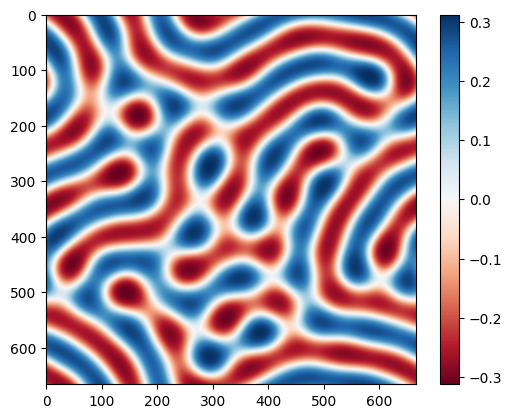

shape: (666, 666), min: -0.312, max: 0.312


In [14]:
u = solve_swift_hohenberg(N=N, steps=2000, r=0.35, ridge=True, gain=0.3)
plt.imshow(u, cmap='RdBu')
plt.colorbar()
plt.show()
print(f"shape: {u.shape}, min: {u.min():.3f}, max: {u.max():.3f}")

In [15]:
u_norm   = u / np.max(np.abs(u))
x_mm     = np.linspace(0, wall_width, N)
y_coords = np.linspace(0, L, N)
print(f"x_mm: 0 to {x_mm[-1]:.1f}mm, {len(x_mm)} points")
print(f"total height: {N * layer_height:.1f}mm")

x_mm: 0 to 200.0mm, 666 points
total height: 199.8mm


In [16]:
def hermite_fillet(p0, t0, p1, t1, n=20):
    p0 = np.array(p0)
    p1 = np.array(p1)
    t0 = np.array(t0, dtype=float)
    t1 = np.array(t1, dtype=float)

    t0 = t0 / np.linalg.norm(t0)
    t1 = t1 / np.linalg.norm(t1)

    d = np.linalg.norm(p1 - p0)
    t0_scaled = t0 * d
    t1_scaled = t1 * d

    pts_x, pts_y = [], []
    for i in range(n + 1):
        s = i / n
        h00 =  2*s**3 - 3*s**2 + 1
        h10 =    s**3 - 2*s**2 + s
        h01 = -2*s**3 + 3*s**2
        h11 =    s**3 -   s**2
        p = h00*p0 + h10*t0_scaled + h01*p1 + h11*t1_scaled
        pts_x.append(p[0])
        pts_y.append(p[1])

    return np.array(pts_x), np.array(pts_y)


def build_layer_with_fillets(x_mm, y_front, y_back, fillet_length=3.0, fillet_pts=20):
    x_left  = x_mm[0]
    x_right = x_mm[-1]

    idx_c1 = np.searchsorted(x_mm, x_left + fillet_length)
    p0_c1 = np.array([x_mm[idx_c1], y_front[idx_c1]])
    t0_c1 = np.array([x_mm[idx_c1] - x_mm[idx_c1-1],
                      y_front[idx_c1] - y_front[idx_c1-1]])
    p1_c1 = np.array([x_left, y_front[0] + fillet_length])
    t1_c1 = np.array([0.0, 1.0])

    idx_c2 = np.searchsorted(x_mm, x_right - fillet_length)
    p0_c2 = np.array([x_mm[idx_c2], y_front[idx_c2]])
    t0_c2 = np.array([x_mm[idx_c2+1] - x_mm[idx_c2],
                      y_front[idx_c2+1] - y_front[idx_c2]])
    p1_c2 = np.array([x_right, y_front[-1] + fillet_length])
    t1_c2 = np.array([0.0, 1.0])

    p0_c3 = np.array([x_right, y_back - fillet_length])
    t0_c3 = np.array([0.0, 1.0])
    p1_c3 = np.array([x_right - fillet_length, y_back])
    t1_c3 = np.array([-1.0, 0.0])

    p0_c4 = np.array([x_left + fillet_length, y_back])
    t0_c4 = np.array([-1.0, 0.0])
    p1_c4 = np.array([x_left, y_back - fillet_length])
    t1_c4 = np.array([0.0, -1.0])

    x_loop, y_loop = [], []

    x_loop.extend(x_mm[idx_c1:idx_c2+1])
    y_loop.extend(y_front[idx_c1:idx_c2+1])

    fx, fy = hermite_fillet(p0_c2, t0_c2, p1_c2, t1_c2, n=fillet_pts)
    x_loop.extend(fx); y_loop.extend(fy)

    x_loop.extend([x_right, x_right])
    y_loop.extend([y_front[-1] + fillet_length, y_back - fillet_length])

    fx, fy = hermite_fillet(p0_c3, t0_c3, p1_c3, t1_c3, n=fillet_pts)
    x_loop.extend(fx); y_loop.extend(fy)

    x_loop.extend([x_right - fillet_length, x_left + fillet_length])
    y_loop.extend([y_back, y_back])

    fx, fy = hermite_fillet(p0_c4, t0_c4, p1_c4, t1_c4, n=fillet_pts)
    x_loop.extend(fx); y_loop.extend(fy)

    x_loop.extend([x_left, x_left])
    y_loop.extend([y_back - fillet_length, y_front[0] + fillet_length])

    fx, fy = hermite_fillet(p1_c1, -t1_c1, p0_c1, t0_c1, n=fillet_pts)
    x_loop.extend(fx); y_loop.extend(fy)

    x_loop.append(x_mm[idx_c1])
    y_loop.append(y_front[idx_c1])

    return np.array(x_loop), np.array(y_loop)


# build layers
layers_filleted = []
for i in range(N):
    z = i * layer_height
    y_front = y_front_center + u_norm[i, :] * y_amplitude

    x_loop, y_loop = build_layer_with_fillets(
        x_mm, y_front, y_back, fillet_length=fillet_length
    )

    layers_filleted.append({
        "layer_index": i,
        "z": z,
        "x_loop": x_loop,
        "y_loop": y_loop
    })

print(f"{len(layers_filleted)} layers built with fillets")
print(f"points per layer: {len(layers_filleted[0]['x_loop'])}")
print(f"total height: {layers_filleted[-1]['z']:.1f}mm")

666 layers built with fillets
points per layer: 738
total height: 199.5mm


In [17]:
fig = go.Figure()

for i, layer in enumerate(layers_filleted):
    if i % 10 != 0:
        continue
    fig.add_trace(go.Scatter3d(
        x=layer["x_loop"],
        y=layer["y_loop"],
        z=[layer["z"]] * len(layer["x_loop"]),
        mode='lines',
        line=dict(color=f'hsl({int(360*i/len(layers_filleted))},80%,50%)', width=2),
        showlegend=False
    ))

fig.update_layout(
    scene=dict(
        xaxis_title='X (mm)',
        yaxis_title='Y (mm)',
        zaxis_title='Z (mm)',
        aspectmode='data'
    ),
    title='Swift-Hohenberg Wall with Hermite Fillets'
)
fig.show()

In [20]:
import math

# --- extrusion calculation ---
def extrusion_length(dist, nozzle_width, layer_height, filament_diameter):
    volume = dist * nozzle_width * layer_height
    return volume / (math.pi * (filament_diameter / 2) ** 2)

def generate_gcode(layers_filleted,
                   nozzle_width        = 0.8,
                   layer_height        = 0.3,
                   filament_diameter   = 1.75,
                   hotend_temp         = 245,
                   bed_temp            = 85,
                   print_speed         = 1800,
                   first_layer_speed   = 900,
                   travel_speed        = 18000,
                   retract_length      = 0.8,
                   retract_speed       = 1500):

    lines = []
    final_z = layers_filleted[-1]["z"]

    # ---- header ----
    lines += [
        "; Swift-Hohenberg vase mode",
        "; generated by sh_fabrication",
        "",
        "G21          ; millimeters",
        "G90          ; absolute XY",
        "M83          ; relative extrusion",
        f"M140 S{bed_temp}    ; bed temp",
        f"M104 S{hotend_temp}  ; hotend temp",
        f"M190 S{bed_temp}    ; wait for bed",
        f"M109 S{hotend_temp}  ; wait for hotend",
        "G28          ; home all axes",
        "G1 Z5 F720   ; lift before prime",
        "G92 E0       ; reset extruder",
        "",
    ]

    for i, layer in enumerate(layers_filleted):
        z      = (i + 1) * layer_height   # start at layer_height not 0
        x_loop = layer["x_loop"]
        y_loop = layer["y_loop"]
        speed  = first_layer_speed if i == 0 else print_speed

        lines.append(f";LAYER_CHANGE")
        lines.append(f";Z:{z:.3f}")
        lines.append(f";HEIGHT:{layer_height}")

        # retract before Z move
        lines.append(f"G1 E-{retract_length:.2f} F{retract_speed}")

        # step Z
        lines.append(f"G1 Z{z:.3f} F720")

        # travel to loop start
        lines.append(f"G1 X{x_loop[0]:.3f} Y{y_loop[0]:.3f} F{travel_speed}")

        # deretract
        lines.append(f"G1 E{retract_length:.2f} F{retract_speed}")

        # extrude around loop
        for j in range(1, len(x_loop)):
            dx   = x_loop[j] - x_loop[j-1]
            dy   = y_loop[j] - y_loop[j-1]
            dist = math.sqrt(dx**2 + dy**2)
            e    = extrusion_length(dist, nozzle_width, layer_height, filament_diameter)
            lines.append(f"G1 X{x_loop[j]:.3f} Y{y_loop[j]:.3f} E{e:.5f} F{speed}")

        # close loop
        dx   = x_loop[0] - x_loop[-1]
        dy   = y_loop[0] - y_loop[-1]
        dist = math.sqrt(dx**2 + dy**2)
        e    = extrusion_length(dist, nozzle_width, layer_height, filament_diameter)
        lines.append(f"G1 X{x_loop[0]:.3f} Y{y_loop[0]:.3f} E{e:.5f} F{speed}")

        lines.append("")

    # ---- footer ----
    lines += [
        f"G1 E-{retract_length:.2f} F{retract_speed}  ; retract",
        f"G1 Z{final_z + 10:.3f} F720                 ; raise head",
        "G1 X125 Y200 F18000                           ; park",
        "M104 S0                                        ; hotend off",
        "M140 S0                                        ; bed off",
        "M84                                            ; motors off",
    ]

    return "\n".join(lines)


gcode = generate_gcode(
    layers_filleted,
    nozzle_width      = nozzle_width,
    layer_height      = layer_height,
    filament_diameter = filament_diameter,
    hotend_temp       = 245,
    bed_temp          = 85,
    print_speed       = 1800,
    first_layer_speed = 900,
    travel_speed      = 18000,
    retract_length    = 0.8,
    retract_speed     = 1500,
)

for line in gcode.split("\n")[:50]:
    print(line)

; Swift-Hohenberg vase mode
; generated by sh_fabrication

G21          ; millimeters
G90          ; absolute XY
M83          ; relative extrusion
M140 S85    ; bed temp
M104 S245  ; hotend temp
M190 S85    ; wait for bed
M109 S245  ; wait for hotend
G28          ; home all axes
G1 Z5 F720   ; lift before prime
G92 E0       ; reset extruder

;LAYER_CHANGE
;Z:0.300
;HEIGHT:0.3
G1 E-0.80 F1500
G1 Z0.300 F720
G1 X3.008 Y17.573 F18000
G1 E0.80 F1500
G1 X3.308 Y17.536 E0.03023 F900
G1 X3.609 Y17.502 E0.03020 F900
G1 X3.910 Y17.471 E0.03017 F900
G1 X4.211 Y17.442 E0.03015 F900
G1 X4.511 Y17.416 E0.03012 F900
G1 X4.812 Y17.392 E0.03010 F900
G1 X5.113 Y17.371 E0.03008 F900
G1 X5.414 Y17.352 E0.03007 F900
G1 X5.714 Y17.335 E0.03006 F900
G1 X6.015 Y17.320 E0.03005 F900
G1 X6.316 Y17.308 E0.03004 F900
G1 X6.617 Y17.297 E0.03003 F900
G1 X6.917 Y17.288 E0.03002 F900
G1 X7.218 Y17.282 E0.03002 F900
G1 X7.519 Y17.277 E0.03001 F900
G1 X7.820 Y17.274 E0.03001 F900
G1 X8.120 Y17.273 E0.03001 F900
G1 X8.

In [23]:
import os

output_gcode = r'C:\Users\georg\Local_Drive\CLIENTS\ZAN-2025_ZANDVOORT_AAN_ZEE\06_Code\gcode\sh_wall.gcode'

with open(output_gcode, 'w') as f:
    f.write(gcode)

print(f"written to {output_gcode}")
print(f"lines: {len(gcode.splitlines())}")
print(f"size: {os.path.getsize(output_gcode) / 1024 / 1024:.1f} MB")

written to C:\Users\georg\Local_Drive\CLIENTS\ZAN-2025_ZANDVOORT_AAN_ZEE\06_Code\gcode\sh_wall.gcode
lines: 496856
size: 16.7 MB
